# Laboratorio 9 — ¿Importa cómo partimos los datos?

**Universidad Rafael Landívar · Facultad de Ingeniería**
Ciencia de Datos · Sección 2 · Segundo semestre 2026
Ing. Max Cerna

**Estudiante:** Smorareq1
**Entrega:** individual. El enunciado pide un trío; en esta entrega la misma persona cubre los tres roles.

| Rol | Qué hizo en este notebook |
|---|---|
| Quien programa | Escribió y ejecutó las partes A–F sin modificar el bloque del modelo |
| Quien registra | Llenó las tablas, las predicciones y la tabla comparativa |
| Quien cuestiona | Dejó por escrito, antes de cada ejecución, qué se esperaba y después contrastó |

**Dataset:** `pedidos_ruta_verde.csv` (pedidos de Ruta Verde, enero–agosto 2026).
**Regla del laboratorio:** el modelo es siempre el mismo (regresión logística M1 y baseline M0). Solo cambia la forma de separar entrenamiento y prueba.

**Uso de IA.** Se usó Cursor para ordenar el notebook, ejecutar el código y redactar la documentación en `docs/`. Cada predicción se escribió como hipótesis antes de mirar la métrica de esa parte, y las respuestas explican el resultado con los números de esta corrida. En la defensa el razonamiento se puede reconstruir sin la herramienta: lo que se mueve no es el modelo, es el corte.


## 1. Preparación

Se carga el archivo y se revisa qué hay antes de entrenar nada.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, recall_score
from sklearn.model_selection import train_test_split, GroupShuffleSplit

ROOT = Path.cwd()
if not (ROOT / "pedidos_ruta_verde.csv").exists():
    ROOT = ROOT.parent
CAPTURAS = ROOT / "docs" / "capturas"
CAPTURAS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ROOT / "pedidos_ruta_verde.csv", parse_dates=["fecha"])
df.info()
print()
print("Nulos por columna")
print(df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   pedido_id              626 non-null    int64         
 1   fecha                  626 non-null    datetime64[us]
 2   departamento           626 non-null    str           
 3   municipio              626 non-null    str           
 4   zona                   626 non-null    str           
 5   restaurante            626 non-null    str           
 6   categoria_restaurante  626 non-null    str           
 7   metodo_pago            626 non-null    str           
 8   total_pedido_gtq       626 non-null    float64       
 9   tiempo_entrega_min     626 non-null    float64       
 10  distancia_km           606 non-null    float64       
 11  calificacion           591 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(6)
memory usage: 58.8 KB

N

### Reconocimiento del set de datos

- **Pedidos:** 626.
- **Restaurantes distintos:** 7 (Pizza Volcán 71 pedidos, Tacos El Chapín 98; el resto queda entre esos dos extremos).
- **Fechas:** del 1 de enero de 2026 al 31 de agosto de 2026.
- **Nulos:** `distancia_km` tiene 20 y `calificacion` tiene 35. El resto de las columnas está completo.
- **`tiempo_entrega_min`:** el mínimo es **−9.5** y el máximo es **196.5**. Hay **4 pedidos con tiempo negativo** (−9.5, −5.8, −3.9 y −3.0). Un tiempo de entrega negativo es imposible: el reloj no corre hacia atrás. 196.5 minutos es extremo (más de tres horas) pero el filtro del enunciado (`> 0` y `< 200`) todavía lo deja entrar. Esos cuatro negativos sí quedarían fuera de la pregunta de regresión.

Otra cosa que se ve al revisar el archivo, y que no se corrige: `metodo_pago` está escrito de dos formas (`Tarjeta` y `TARJETA`, igual con efectivo y transferencia). Son 15 filas con el texto en mayúsculas. Unificarlas cambiaría las columnas que ve el modelo y rompería la comparación con otros grupos, así que se dejan como vienen.


In [2]:
print("Pedidos:", len(df))
print("Restaurantes:", df["restaurante"].nunique())
print(df["restaurante"].value_counts())
print("Desde", df["fecha"].min().date(), "hasta", df["fecha"].max().date())
print("tiempo_entrega_min  min =", df["tiempo_entrega_min"].min(), " max =", df["tiempo_entrega_min"].max())
print("Tiempos imposibles (<= 0):", int((df["tiempo_entrega_min"] <= 0).sum()))
print("Metodos de pago:")
print(df["metodo_pago"].value_counts())


Pedidos: 626
Restaurantes: 7
restaurante
Tacos El Chapín      98
Burger Xelajú        97
Pollo Real           93
Café Chuwa           91
Pupusas Doña Lupe    91
Sushi Ixchel         85
Pizza Volcán         71
Name: count, dtype: int64
Desde 2026-01-01 hasta 2026-08-31
tiempo_entrega_min  min = -9.5  max = 196.5
Tiempos imposibles (<= 0): 4
Metodos de pago:
metodo_pago
Tarjeta          309
Efectivo         223
Transferencia     79
EFECTIVO           7
TARJETA            6
TRANSFERENCIA      2
Name: count, dtype: int64


## 2. Las dos preguntas de negocio

La pregunta que se mide en todo el laboratorio es la de clasificación: ¿este pedido recibirá calificación baja? (1 o 2 estrellas). La de regresión queda planteada para saber qué columnas no se podrían usar.


In [3]:
cal = df.dropna(subset=["calificacion"]).copy()
cal["baja"] = (cal["calificacion"] <= 2).astype(int)
print("Pedidos con calificacion:", len(cal))
print("Proporcion de calificacion baja:", round(cal["baja"].mean(), 4))
print(cal["baja"].value_counts())

reg = df[(df.tiempo_entrega_min > 0) & (df.tiempo_entrega_min < 200)].copy()
print("Pedidos utiles para la pregunta de tiempo:", len(reg), "de", len(df))


Pedidos con calificacion: 591
Proporcion de calificacion baja: 0.0914
baja
0    537
1     54
Name: count, dtype: int64
Pedidos utiles para la pregunta de tiempo: 622 de 626


### Pregunta 1

Si se quiere predecir el tiempo de entrega **en el momento en que entra el pedido**, estas columnas no se pueden usar como insumo:

- **`tiempo_entrega_min`.** Es justo lo que se quiere predecir. Cuando el pedido entra, la entrega todavía no ocurrió.
- **`calificacion`.** El cliente califica después de recibir. En el momento del pedido ese número no existe.

El resto sí existe en ese momento: fecha, departamento, municipio, zona, restaurante, categoría, método de pago y total. La distancia también: se puede estimar con la dirección del local y la del cliente antes de salir el repartidor.

Por eso el modelo de este laboratorio no usa ni el tiempo ni la calificación como columnas de entrada. La calificación solo entra como la etiqueta `baja`.


## 3. Definición del modelo

El bloque siguiente va copiado del enunciado. No se cambia entre una parte y otra. M1 es una regresión logística: rellena nulos numéricos con la mediana, escala esas columnas y convierte las categóricas en columnas 0/1. M0 es el baseline: siempre responde la clase más común.


In [4]:
NUM = ["distancia_km", "total_pedido_gtq"]
CAT = ["zona", "categoria_restaurante", "metodo_pago"]
FEATURES = NUM + CAT

def nuevo_modelo():
    """M1. Siempre se crea nuevo; nunca se reutiliza uno ya entrenado."""
    prep = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("esc", StandardScaler())]), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
    ])
    return Pipeline([
        ("prep", prep),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])

def entrenar_y_medir(train, test, target="baja"):
    """Entrena M1 con train, mide en test y devuelve F1 y recall."""
    m = nuevo_modelo()
    m.fit(train[FEATURES], train[target])
    pred = m.predict(test[FEATURES])
    return {"f1": f1_score(test[target], pred),
            "recall": recall_score(test[target], pred),
            "n_test": len(test),
            "positivos_test": int(test[target].sum())}

def medir_baseline(train, test, target="baja"):
    """M0: modelo tonto. Predice siempre la clase más común."""
    d = DummyClassifier(strategy="most_frequent")
    d.fit(train[FEATURES], train[target])
    return f1_score(test[target], d.predict(test[FEATURES]))


### Pregunta 2 — predicción, antes de ejecutar

**Predicción:** el F1 de M0 va a ser **0**.

Cerca del 9 % de los pedidos calificados son "baja". La clase más común es "no baja". Un modelo que siempre responde "no será baja" no acierta ni un positivo: el recall de la clase baja es 0 y, con él, el F1 también es 0. No importa cómo se partan los datos, mientras "no baja" siga siendo mayoría en el train.


## 4. Parte A — cinco cortes al azar

Se separa 80 % train y 20 % test. Lo único que cambia es `random_state`.

**Predicción del grupo, antes de ejecutar:** el F1 no va a salir idéntico, pero tampoco muy distinto. El modelo es el mismo y el 80/20 también. Esperamos cifras parecidas, con una brecha de unas pocas centésimas entre la mejor semilla y la peor.


In [5]:
filas = []
for semilla in [0, 1, 7, 42, 2026]:
    train, test = train_test_split(cal, test_size=0.2, random_state=semilla)
    r = entrenar_y_medir(train, test)
    r["semilla"] = semilla
    r["f1_baseline"] = medir_baseline(train, test)
    filas.append(r)

tabla_a = pd.DataFrame(filas)
tabla_a["pct_positivos"] = tabla_a["positivos_test"] / tabla_a["n_test"]
tabla_a = tabla_a[["semilla", "positivos_test", "pct_positivos", "f1", "recall", "f1_baseline"]]

resumen_a = pd.DataFrame([{
    "semilla": "min – max",
    "positivos_test": f"{int(tabla_a['positivos_test'].min())} – {int(tabla_a['positivos_test'].max())}",
    "pct_positivos": f"{tabla_a['pct_positivos'].min():.1%} – {tabla_a['pct_positivos'].max():.1%}",
    "f1": f"{tabla_a['f1'].min():.3f} – {tabla_a['f1'].max():.3f}",
    "recall": f"{tabla_a['recall'].min():.3f} – {tabla_a['recall'].max():.3f}",
    "f1_baseline": f"{tabla_a['f1_baseline'].min():.3f} – {tabla_a['f1_baseline'].max():.3f}",
}])
vista_a = pd.concat([tabla_a.astype(object), resumen_a], ignore_index=True)
vista_a


,semilla,positivos_test,pct_positivos,f1,recall,f1_baseline
0,0,15,0.12605,0.226415,0.4,0.0
1,1,12,0.10084,0.245614,0.583333,0.0
2,7,11,0.092437,0.113208,0.272727,0.0
3,42,14,0.117647,0.166667,0.357143,0.0
4,2026,3,0.02521,0.095238,0.666667,0.0
5,min – max,3 – 15,2.5% – 12.6%,0.095 – 0.246,0.273 – 0.667,0.000 – 0.000


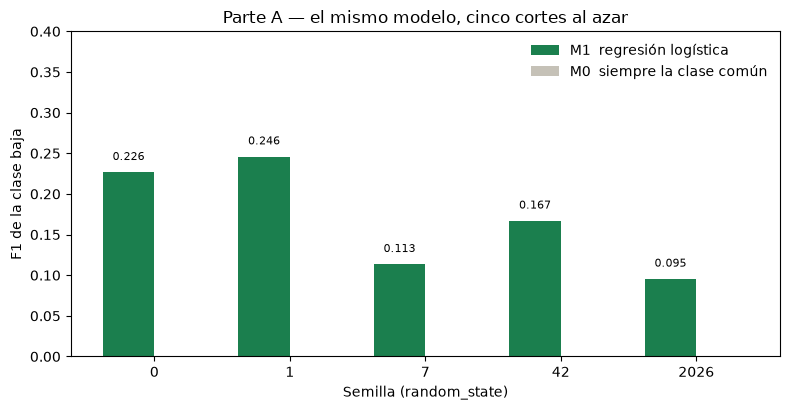

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(tabla_a))
ancho = 0.38
ax.bar(x - ancho / 2, tabla_a["f1"], ancho, color="#1B7F4E", label="M1  regresión logística")
ax.bar(x + ancho / 2, tabla_a["f1_baseline"], ancho, color="#C5C1B7", label="M0  siempre la clase común")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in tabla_a["semilla"]])
ax.set_xlabel("Semilla (random_state)")
ax.set_ylabel("F1 de la clase baja")
ax.set_ylim(0, 0.40)
ax.set_title("Parte A — el mismo modelo, cinco cortes al azar")
ax.legend(frameon=False)
for i, row in tabla_a.iterrows():
    ax.text(i - ancho / 2, row["f1"] + 0.012, f"{row['f1']:.3f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(CAPTURAS / "parte_a_f1_por_semilla.png", dpi=140)
plt.show()


### Pregunta 3

La predicción se quedó corta. No fue una diferencia de centésimas.

| Semilla | Positivos en test | % positivos | F1 de M1 | F1 de M0 |
|---|---:|---:|---:|---:|
| 0 | 15 | 12.6 % | 0.226 | 0.000 |
| 1 | 12 | 10.1 % | **0.246** | 0.000 |
| 7 | 11 | 9.2 % | 0.113 | 0.000 |
| 42 | 14 | 11.8 % | 0.167 | 0.000 |
| 2026 | 3 | 2.5 % | **0.095** | 0.000 |
| mín – máx | 3 – 15 | 2.5 % – 12.6 % | 0.095 – 0.246 | 0 – 0 |

Entre el mejor F1 (semilla 1, **0.246**) y el peor (semilla 2026, **0.095**) hay **0.150**. Es mucho: el mismo modelo, con los mismos datos, parece más del doble de bueno solo porque la semilla repartió otros pedidos al test. El promedio de las cinco semillas es **0.169**.

M0 dio **0** en las cinco. La predicción de la pregunta 2 sí acertó.

### Pregunta 4

Si otro grupo reporta otro F1 con este mismo modelo y este mismo archivo, **los dos pueden tener razón**. Cada semilla es un corte distinto y el test tiene solo 119 pedidos, de los cuales muy pocos son "baja". Con tan pocos positivos, el F1 se mueve fácil.

El número que no debería reportarse es el mejor de la tabla. Ese es el corte que más nos favorece. Lo honesto, si se va a usar un corte al azar, es el rango (0.095 a 0.246) o el promedio (0.169), junto con el F1 de M0, que aquí es 0. Un solo F1 sin decir la semilla no se puede comparar entre grupos.

### Pregunta 5

La columna de positivos y el F1 se mueven juntos, pero no en línea recta. La semilla 2026 deja **3 positivos** en el test (2.5 %, contra ~9 % del archivo) y saca el peor F1 (0.095). Con tres casos, fallar uno cambia el recall de golpe, y además el modelo marca muchos pedidos sanos como bajos: la precisión se cae y el F1 la acompaña.

No alcanza con decir "más positivos, mejor F1". La semilla 0 tiene la mayor cantidad (15) y su F1 (0.226) no supera a la semilla 1 (12 positivos, F1 0.246). Lo que sí se ve es que **cuando el test no representa la proporción real, el F1 deja de ser comparable**. La semilla 2026 no midió el mismo problema que las otras.


## 5. Parte B — forzar la proporción (`stratify`)

`stratify` obliga a que train y test tengan la misma proporción de cada clase que el archivo completo.

**Predicción del grupo, antes de ejecutar:** el F1 promedio no va a subir de forma clara. Lo que va a cambiar es la dispersión: el porcentaje de positivos en el test va a quedar fijo y las cinco semillas se van a parecer más entre sí. Stratify no le enseña nada nuevo al modelo; solo evita un test desbalanceado por suerte.


In [7]:
filas_b = []
for semilla in [0, 1, 7, 42, 2026]:
    train, test = train_test_split(
        cal, test_size=0.2, random_state=semilla, stratify=cal["baja"]
    )
    r = entrenar_y_medir(train, test)
    r["semilla"] = semilla
    r["f1_baseline"] = medir_baseline(train, test)
    filas_b.append(r)

tabla_b = pd.DataFrame(filas_b)
tabla_b["pct_positivos"] = tabla_b["positivos_test"] / tabla_b["n_test"]
tabla_b = tabla_b[["semilla", "positivos_test", "pct_positivos", "f1", "recall", "f1_baseline"]]
tabla_b


,semilla,positivos_test,pct_positivos,f1,recall,f1_baseline
0,0,11,0.092437,0.145455,0.363636,0.0
1,1,11,0.092437,0.212766,0.454545,0.0
2,7,11,0.092437,0.156250,0.454545,0.0
3,42,11,0.092437,0.229508,0.636364,0.0
4,2026,11,0.092437,0.140351,0.363636,0.0


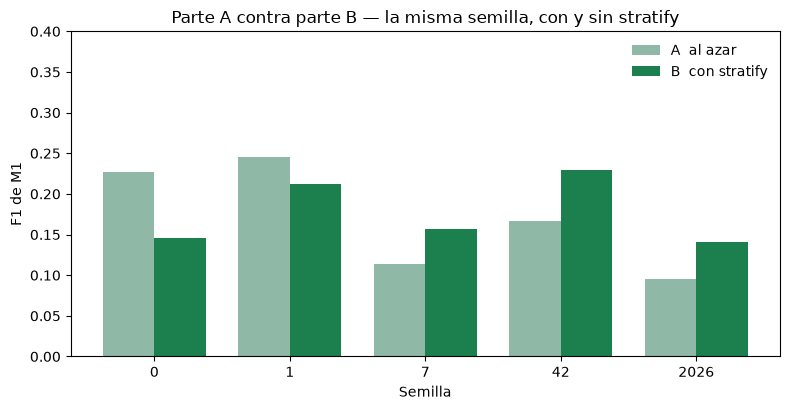

Promedio F1  A: 0.169   brecha: 0.15
Promedio F1  B: 0.177   brecha: 0.089
Positivos en test, parte B: [11]


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(tabla_a))
ancho = 0.38
ax.bar(x - ancho / 2, tabla_a["f1"], ancho, color="#8FB9A6", label="A  al azar")
ax.bar(x + ancho / 2, tabla_b["f1"], ancho, color="#1B7F4E", label="B  con stratify")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in tabla_a["semilla"]])
ax.set_xlabel("Semilla")
ax.set_ylabel("F1 de M1")
ax.set_ylim(0, 0.40)
ax.set_title("Parte A contra parte B — la misma semilla, con y sin stratify")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(CAPTURAS / "parte_ab_comparacion.png", dpi=140)
plt.show()

print("Promedio F1  A:", round(tabla_a["f1"].mean(), 3), "  brecha:", round(tabla_a["f1"].max() - tabla_a["f1"].min(), 3))
print("Promedio F1  B:", round(tabla_b["f1"].mean(), 3), "  brecha:", round(tabla_b["f1"].max() - tabla_b["f1"].min(), 3))
print("Positivos en test, parte B:", sorted(tabla_b["positivos_test"].unique().tolist()))


### Pregunta 6

Cambian las dos cosas, pero no en la misma medida.

| | Promedio del F1 | Brecha (máx − mín) | Positivos en el test |
|---|---:|---:|---|
| A, al azar | 0.169 | 0.150 | de 3 a 15 |
| B, con stratify | 0.177 | 0.089 | 11 en las cinco semillas |

El promedio sube muy poco (de 0.169 a 0.177). La brecha entre semillas baja de 0.150 a 0.089, y desaparece el caso raro de la semilla 2026, que se había quedado con 3 positivos. Con stratify las cinco pruebas miran un test con **11 bajas, el 9.2 %**, que es la proporción del archivo (9.1 %).

La predicción apuntaba a la dispersión y no a una subida del promedio. Eso es lo que pasó. La subida del promedio es un efecto chico al lado del recorte de la brecha.

### Pregunta 7

Stratify **no hace que el modelo prediga mejor**. El algoritmo es el mismo y no ve columnas nuevas. Lo que hace es que la medición sea más justa: train y test heredan la proporción de clases del archivo, así que una semilla no puede armar un test casi sin casos "baja".

El F1 de cada semilla sigue moviéndose (0.140 a 0.230) porque los pedidos concretos del test cambian. Stratify controla el *cuántos*, no el *cuáles*.

### Pregunta 8

Stratify es indispensable cuando la clase que importa es escasa y el test es chico. Aquí "baja" es el 9 % y el test tiene 119 filas: sin stratify, una semilla dejó 3 positivos y el F1 se desplomó por la muestra, no porque el modelo hubiera empeorado.

Da casi igual usarlo cuando las clases están parejas (cerca de 50/50) y el test es grande. Ahí el azar ya conserva la proporción y stratify no mueve la medición.


## 6. Parte C — separar por fecha

Hasta aquí el azar mezcló pedidos de todos los meses. Ahora se mira el porcentaje de calificación baja mes a mes, y después se entrena con el pasado y se prueba con el futuro.


In [9]:
mensual = (
    cal.assign(mes=cal["fecha"].dt.to_period("M"))
    .groupby("mes")
    .agg(pedidos=("baja", "size"), positivos=("baja", "sum"), pct=("baja", "mean"))
    .reset_index()
)
mensual["mes"] = mensual["mes"].astype(str)
mensual


,mes,pedidos,positivos,pct
0,2026-01,70,5,0.071429
1,2026-02,81,8,0.098765
2,2026-03,79,8,0.101266
3,2026-04,77,6,0.077922
4,2026-05,60,4,0.066667
5,2026-06,75,9,0.120000
6,2026-07,76,1,0.013158
7,2026-08,73,13,0.178082


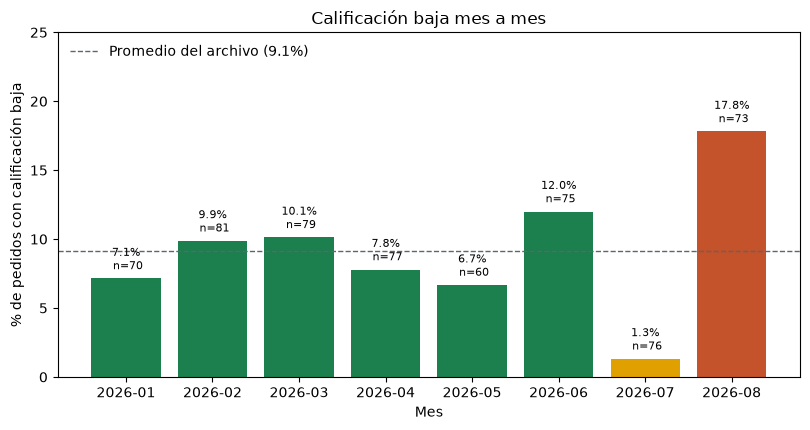

In [10]:
colores = ["#1B7F4E" if m < "2026-07" else ("#E0A100" if m == "2026-07" else "#C4522A") for m in mensual["mes"]]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
bars = ax.bar(mensual["mes"], mensual["pct"] * 100, color=colores)
ax.axhline(cal["baja"].mean() * 100, color="#5C6570", ls="--", lw=1, label=f"Promedio del archivo ({cal['baja'].mean():.1%})")
ax.set_ylabel("% de pedidos con calificación baja")
ax.set_xlabel("Mes")
ax.set_title("Calificación baja mes a mes")
ax.set_ylim(0, 25)
for bar, pct, n in zip(bars, mensual["pct"], mensual["pedidos"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f"{pct:.1%}\n n={n}", ha="center", va="bottom", fontsize=8)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(CAPTURAS / "parte_c_baja_por_mes.png", dpi=140)
plt.show()


Julio y agosto no se parecen ni entre sí ni al primer semestre.

- De enero a junio la tasa anda entre 6.7 % y 12.0 %.
- **Julio cae a 1.3 %** (1 pedido bajo de 76).
- **Agosto sube a 17.8 %** (13 de 73), el peor mes del archivo.

El promedio de julio–agosto, juntando los dos meses, vuelve a quedar cerca del 9 %. El promedio esconde el quiebre.

**Predicción del grupo, después de ver la gráfica y antes de medir:** el F1 va a salir **peor** que con el corte al azar. El modelo va a aprender el patrón de enero–junio y va a ser examinado en un período que cambió de comportamiento: un julio casi sin quejas y un agosto con casi el doble de la tasa habitual.


In [11]:
train_t = cal[cal.fecha < "2026-07-01"]
test_t = cal[cal.fecha >= "2026-07-01"]
print("Train ene–jun:", len(train_t), " tasa baja:", round(train_t["baja"].mean(), 4))
print("Test  jul–ago:", len(test_t), " tasa baja:", round(test_t["baja"].mean(), 4))
resultado_c = entrenar_y_medir(train_t, test_t)
baseline_c = medir_baseline(train_t, test_t)
print("M1:", resultado_c)
print("M0 F1:", baseline_c)


Train ene–jun: 442  tasa baja: 0.0905
Test  jul–ago: 149  tasa baja: 0.094
M1: {'f1': 0.037037037037037035, 'recall': 0.07142857142857142, 'n_test': 149, 'positivos_test': 14}
M0 F1: 0.0


### Pregunta 9

La predicción acertó, y el golpe fue más fuerte de lo que se esperaba.

| Corte | F1 de M1 | F1 de M0 | Recall de M1 |
|---|---:|---:|---:|
| A, promedio de las cinco semillas | 0.169 | 0.000 | — |
| C, entrenar ene–jun y probar jul–ago | **0.037** | 0.000 | 0.071 |

El F1 temporal es **0.037**. El recall es 0.071: de 14 pedidos bajos en julio–agosto, el modelo marca bien uno. M0 sigue en 0, así que M1 le gana al baseline, pero por muy poco y sin servirle a la operación.

La tasa global del test (9.4 %) es casi la del train (9.0 %). No falló porque "hubiera más o menos bajas en promedio". Falló porque **el fenómeno cambió de forma dentro del período**: julio está casi vacío de bajas y agosto concentra 13 de las 14. Un modelo entrenado con un semestre estable no reconoce ese quiebre. El corte al azar nunca lo muestra, porque mete pedidos de agosto en el train y el modelo alcanza a ver el futuro.

### Pregunta 10

Ruta Verde quiere usar el modelo en septiembre, con pedidos que todavía no existen. De las dos mediciones, **la de fecha se parece más a esa situación**.

En septiembre el modelo solo podrá haber aprendido de lo ya ocurrido (enero–agosto, o los meses que se le den). No va a poder entrenar con pedidos de septiembre mezclados entre el train. El corte al azar sí hace eso: deja que un pedido del 8 de agosto enseñe y uno de febrero evalúe. Esa medición contesta otra pregunta: "¿qué tal si el futuro se parece a una mezcla del pasado?", no "¿qué tal nos irá el mes que viene?".

### Pregunta 11

Tiene de raro que **el examen usa el futuro para estudiar**. Si un pedido del 8 de agosto está en el train, el modelo ya vio cómo se comportó agosto. Probarlo con un pedido del 3 de febrero no simula el uso real: en producción nunca se predice febrero después de haber aprendido agosto. El tiempo corre en una sola dirección. Un corte que lo ignora infla la nota.


## 7. Parte D — separar por restaurante

Ruta Verde trabaja con 7 restaurantes. Primero se cuenta, en un corte al azar, cuántos restaurantes del test también están en el train. Después se dejan dos restaurantes completos fuera del entrenamiento.

**Predicción del grupo, antes del group split:** el F1 va a bajar frente al corte al azar. Esos dos restaurantes no aportan ningún pedido al train, y su mezcla de tickets, zonas y quejas puede no parecerse a la de los otros cinco.


In [12]:
train_r, test_r = train_test_split(cal, test_size=0.2, random_state=42)
en_test = set(test_r["restaurante"].unique())
en_train = set(train_r["restaurante"].unique())
print("Restaurantes en el test:", len(en_test))
print("De esos, también están en el train:", len(en_test & en_train))
print("Solo en el test:", sorted(en_test - en_train) or "ninguno")

gss = GroupShuffleSplit(n_splits=1, test_size=2 / 7, random_state=42)
i_tr, i_te = next(gss.split(cal, cal["baja"], groups=cal["restaurante"]))
train_g, test_g = cal.iloc[i_tr], cal.iloc[i_te]
print("Train:", sorted(train_g["restaurante"].unique()))
print("Test: ", sorted(test_g["restaurante"].unique()))
print("Tasa baja train:", round(train_g["baja"].mean(), 4), " test:", round(test_g["baja"].mean(), 4))
resultado_d = entrenar_y_medir(train_g, test_g)
baseline_d = medir_baseline(train_g, test_g)
print("M1:", resultado_d)
print("M0 F1:", baseline_d)


Restaurantes en el test: 7
De esos, también están en el train: 7
Solo en el test: ninguno
Train: ['Pizza Volcán', 'Pollo Real', 'Pupusas Doña Lupe', 'Sushi Ixchel', 'Tacos El Chapín']
Test:  ['Burger Xelajú', 'Café Chuwa']
Tasa baja train: 0.0969  test: 0.0787
M1: {'f1': 0.10344827586206896, 'recall': 0.21428571428571427, 'n_test': 178, 'positivos_test': 14}
M0 F1: 0.0


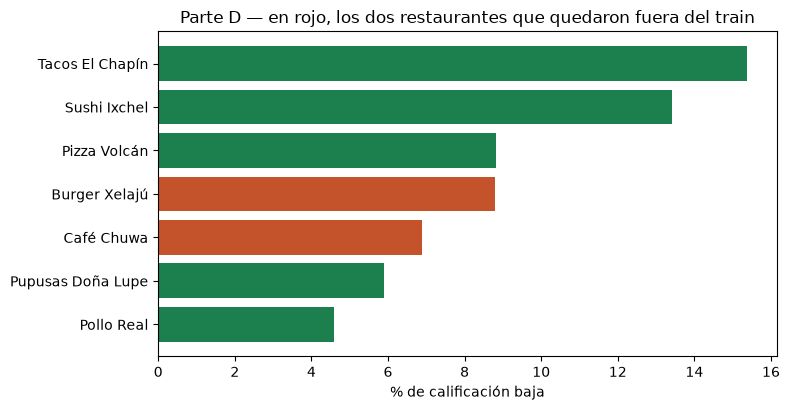

In [13]:
por_rest = (
    cal.groupby("restaurante")
    .agg(pedidos=("baja", "size"), pct=("baja", "mean"))
    .sort_values("pct")
)
fig, ax = plt.subplots(figsize=(8, 4.2))
colores = ["#C4522A" if r in set(test_g["restaurante"]) else "#1B7F4E" for r in por_rest.index]
ax.barh(por_rest.index.astype(str), por_rest["pct"] * 100, color=colores)
ax.set_xlabel("% de calificación baja")
ax.set_title("Parte D — en rojo, los dos restaurantes que quedaron fuera del train")
fig.tight_layout()
fig.savefig(CAPTURAS / "parte_d_por_restaurante.png", dpi=140)
plt.show()


### Paso 1

En el corte al azar con semilla 42, **los 7 restaurantes del test también están en el train**. No hay ninguno que el modelo vea por primera vez en el examen. El corte al azar no responde "¿qué pasa con un local nuevo?".

### Pregunta 12

El group split dejó fuera a **Burger Xelajú** y **Café Chuwa**.

| | F1 de M1 | F1 de M0 | Recall |
|---|---:|---:|---:|
| A, promedio | 0.169 | 0.000 | — |
| D, dos restaurantes fuera | **0.103** | 0.000 | 0.214 |

El F1 bajó a **0.103**. La predicción acertó en la dirección.

No bajó hasta el nivel del corte por fecha (0.037). El modelo no usa el nombre del restaurante: usa zona, categoría, método de pago, distancia y total. Esas columnas también existen en un local nuevo, así que algo se transfiere. Aun así, cada restaurante tiene su propia tasa de bajas (Pollo Real anda en 4.6 %, Tacos El Chapín en 15.4 %) y el modelo, al no haber visto esos pedidos, no hereda ese historial. Burger Xelajú y Café Chuwa están en la mitad baja de quejas; el train, en cambio, incluye a los dos locales con más bajas. El examen no es el mismo problema que el estudio.

### Pregunta 13

Mañana Ruta Verde firma con un restaurante que nunca ha tenido pedidos. De todas las mediciones, **la parte D es la que mejor describe cómo se va a portar el modelo con ese local**.

El corte al azar y el estratificado ponen pedidos de los mismos siete restaurantes en los dos lados. El corte por fecha cambia el mes, pero los locales son los mismos. Solo el group split obliga al modelo a puntuar pedidos de alguien que no estuvo en el entrenamiento. Un restaurante nuevo se parece a eso: no hay historial suyo dentro del train. El F1 de 0.103 es la referencia; el 0.246 de la mejor semilla no lo es.


## 8. Parte E — un atajo tentador

Como el restaurante parece influir, se agrega `riesgo_rest`: el promedio histórico de calificaciones bajas de cada local. Hay dos maneras de calcularlo.

**Predicción del grupo, antes de ejecutar:** la versión 1 va a dar **mejor F1**. Calcula el promedio con todos los pedidos, incluidos los del test, y después parte. El modelo alcanza a ver, de forma indirecta, cómo les fue a los pedidos con los que luego se le va a examinar. La versión 2 calcula el promedio solo con el train: eso es lo único que existiría si el test todavía no hubiera ocurrido.


In [14]:
# Version 1: el promedio ve tambien el test, y recien despues se parte.
prom = cal.groupby("restaurante")["baja"].mean()
cal_v1 = cal.assign(riesgo_rest=cal["restaurante"].map(prom))

NUM = ["distancia_km", "total_pedido_gtq", "riesgo_rest"]
FEATURES = NUM + CAT
train_v1, test_v1 = train_test_split(
    cal_v1, test_size=0.2, random_state=42, stratify=cal_v1["baja"]
)
resultado_e1 = entrenar_y_medir(train_v1, test_v1)
baseline_e1 = medir_baseline(train_v1, test_v1)

# Version 2: primero se parte, y el promedio solo usa el train.
NUM = ["distancia_km", "total_pedido_gtq"]
FEATURES = NUM + CAT
train_e, test_e = train_test_split(
    cal, test_size=0.2, random_state=42, stratify=cal["baja"]
)
prom_tr = train_e.groupby("restaurante")["baja"].mean()
train_v2 = train_e.assign(riesgo_rest=train_e["restaurante"].map(prom_tr))
test_v2 = test_e.assign(riesgo_rest=test_e["restaurante"].map(prom_tr))

NUM = ["distancia_km", "total_pedido_gtq", "riesgo_rest"]
FEATURES = NUM + CAT
resultado_e2 = entrenar_y_medir(train_v2, test_v2)
baseline_e2 = medir_baseline(train_v2, test_v2)

# Se deja el modelo como al inicio, para el resto del notebook.
NUM = ["distancia_km", "total_pedido_gtq"]
FEATURES = NUM + CAT

print("V1 (promedio con todo) ", resultado_e1, " M0", baseline_e1)
print("V2 (promedio con train)", resultado_e2, " M0", baseline_e2)
print()
comparacion_prom = pd.DataFrame({"con_todo": prom, "solo_train": prom_tr})
comparacion_prom["diferencia"] = comparacion_prom["con_todo"] - comparacion_prom["solo_train"]
comparacion_prom.round(4)


V1 (promedio con todo)  {'f1': 0.22950819672131148, 'recall': 0.6363636363636364, 'n_test': 119, 'positivos_test': 11}  M0 0.0
V2 (promedio con train) {'f1': 0.22950819672131148, 'recall': 0.6363636363636364, 'n_test': 119, 'positivos_test': 11}  M0 0.0



,con_todo,solo_train,diferencia
restaurante,,,
Burger Xelajú,0.0879,0.0789,0.0090
Café Chuwa,0.0690,0.0769,-0.0080
Pizza Volcán,0.0882,0.1034,-0.0152
Pollo Real,0.0460,0.0441,0.0019
Pupusas Doña Lupe,0.0588,0.0685,-0.0097
Sushi Ixchel,0.1341,0.1538,-0.0197
Tacos El Chapín,0.1538,0.1194,0.0344


### Pregunta 14

**Ninguna dio mejor.** Las dos sacaron el mismo F1: **0.230**, el mismo recall (0.636) y el mismo M0 (0). Es el mismo número de la parte B con semilla 42, que no usaba `riesgo_rest`. La columna nueva no cambió la medición.

La predicción falló. Se esperaba que la versión 1 ganara por haber espiado el test, y en esta corrida no se notó.

La versión 1 sí tenía información que la versión 2 no tenía: la etiqueta `baja` de los pedidos que después cayeron en el test, metida dentro del promedio de cada restaurante. La diferencia entre los dos promedios es chica (entre una y tres centésimas; en Tacos El Chapín llega a 0.034) porque los siete restaurantes aparecen en el train y en el test, y el train ya se lleva el 80 % de los pedidos. Con una columna tan parecida, la regresión logística no cambió ninguna predicción del test. El atajo estaba ahí; en este corte no alcanzó a mover el F1.

Eso no lo vuelve inocente. Si un restaurante hubiera quedado solo en el test, la versión 1 le habría calculado el riesgo con las mismas calificaciones que después usa para examinarse. La versión 2, en ese caso, no tendría promedio para asignarle.

### Pregunta 15

Si se entrega la versión 1 como resultado oficial y el modelo se pone en producción, **el número no se va a sostener**.

Un pedido nuevo todavía no tiene calificación. El promedio del restaurante solo puede armarse con pedidos ya cerrados, que es lo que hace la versión 2. La versión 1 usó calificaciones que, en la vida real, aún no existen. En esta corrida las dos coincidieron, así que el informe no mostraría una caída inmediata; el problema es de procedimiento. El día en que el historial del train y el del archivo completo se separen más —un local con pocos pedidos, o un mes malo que se cuela en el promedio— el F1 de la versión 1 va a quedar por encima de lo que el modelo entrega de verdad.

### Pregunta 16

El mismo problema lo tendrían la mediana del `SimpleImputer` y la media y la desviación del `StandardScaler` si se calcularan **antes** de partir.

Dentro de M1 eso no pasa: el imputer y el scaler viven dentro del `Pipeline`, y el `fit` solo ve el train. La mediana y la escala salen de los pedidos de entrenamiento y después se aplican al test. Si alguien rellena nulos o estandariza el archivo completo y después hace el `train_test_split`, el test participa en unos números que se supone que no conoce. Es la misma fuga que `riesgo_rest` en la versión 1, solo que escondida en el preprocesamiento.


## 9. Parte F — la recomendación

### Qué número se le reporta al gerente

El número que se reporta como desempeño esperado es el de la **parte C: F1 = 0.037**, con M0 en 0, entrenando con enero–junio y probando con julio–agosto.

Es el corte que se parece a septiembre: el modelo solo conoce el pasado y los pedidos de mañana todavía no están en los datos. El 0.246 de la mejor semilla no se reporta. Es el mismo modelo en su corte más amable, y la parte C muestra que esa amabilidad no sobrevive cuando el tiempo avanza.

Conviene decirlo completo, no solo el F1. M1 le gana a un modelo que nunca marca una calificación baja, pero 0.037 es un detector flojo: en julio–agosto atrapó 1 de 14 pedidos bajos. No es un modelo para operar todavía. El número honesto también sirve para no venderlo de más.

### Qué corte usar en cada escenario

| Escenario | Corte | Por qué |
|---|---|---|
| (a) El modelo corre cada noche sobre los pedidos del día siguiente | Por fecha, train = pasado y test = futuro (parte C) | Mañana no se puede colar en el entrenamiento de hoy |
| (b) Saber si sirve para restaurantes nuevos | Por restaurante, dejando locales completos fuera (parte D) | Un local nuevo no tiene pedidos dentro del train |
| (c) Solo comparar dos modelos entre sí, con los datos actuales | Aleatorio **con stratify**, y reportar el promedio de varias semillas, no la mejor (parte B) | Aquí no se simula el futuro ni un local nuevo; se busca que la comparación no dependa de una semilla suertuda |

### Pregunta 17

La medición **más alta** fue la parte A con semilla 1: **F1 = 0.246**.

La **más confiable** para decirle a Ruta Verde cómo le irá con pedidos que todavía no existen es la parte C: **F1 = 0.037**.

No son la misma. La más alta es la más optimista: un test al azar que, además, en otras semillas baja hasta 0.095. La más confiable es la que respeta el orden del tiempo, y esa cuenta otra historia. Elegir el máximo de la tabla sería reportar la suerte del corte, no el desempeño del modelo.


## 10. Tabla comparativa

Una fila por experimento. En la parte B se reporta el promedio de las cinco semillas, no la semilla que más conviene.


In [15]:
comparativa = pd.DataFrame([
    ["A · aleatorio, mejor semilla (1)", round(float(tabla_a.loc[tabla_a["semilla"] == 1, "f1"].iloc[0]), 3), 0.0,
     "Pedidos de todos los meses mezclados; el corte que más favoreció a M1"],
    ["A · aleatorio, peor semilla (2026)", round(float(tabla_a.loc[tabla_a["semilla"] == 2026, "f1"].iloc[0]), 3), 0.0,
     "El mismo azar, pero el test se quedó con 3 calificaciones bajas"],
    ["B · con stratify (promedio de 5 semillas)", round(float(tabla_b["f1"].mean()), 3), 0.0,
     "Azar que conserva el 9.2 % de bajas en el test. Sirve para comparar modelos"],
    ["C · por fecha (jul–ago)", round(float(resultado_c["f1"]), 3), round(float(baseline_c), 3),
     "Usar el modelo en septiembre, con pedidos que todavía no existen"],
    ["D · por restaurante", round(float(resultado_d["f1"]), 3), round(float(baseline_d), 3),
     "Un restaurante nuevo, que no aportó pedidos al entrenamiento"],
    ["E · versión 1 (promedio con todo)", round(float(resultado_e1["f1"]), 3), round(float(baseline_e1), 3),
     "El historial del restaurante se calculó espiando también el test"],
    ["E · versión 2 (promedio con train)", round(float(resultado_e2["f1"]), 3), round(float(baseline_e2), 3),
     "El mismo historial, calculado solo con pedidos que el modelo podía conocer"],
], columns=["Experimento", "F1 de M1", "F1 de M0", "Qué situación real simula"])
comparativa.to_csv(ROOT / "docs" / "tabla_comparativa.csv", index=False)
comparativa


,Experimento,F1 de M1,F1 de M0,Qué situación real simula
0,"A · aleatorio, mejor semilla (1)",0.246,0.0,Pedidos de todos los meses mezclados; el corte...
1,"A · aleatorio, peor semilla (2026)",0.095,0.0,"El mismo azar, pero el test se quedó con 3 cal..."
2,B · con stratify (promedio de 5 semillas),0.177,0.0,Azar que conserva el 9.2 % de bajas en el test...
3,C · por fecha (jul–ago),0.037,0.0,"Usar el modelo en septiembre, con pedidos que ..."
4,D · por restaurante,0.103,0.0,"Un restaurante nuevo, que no aportó pedidos al..."
5,E · versión 1 (promedio con todo),0.230,0.0,El historial del restaurante se calculó espian...
6,E · versión 2 (promedio con train),0.230,0.0,"El mismo historial, calculado solo con pedidos..."


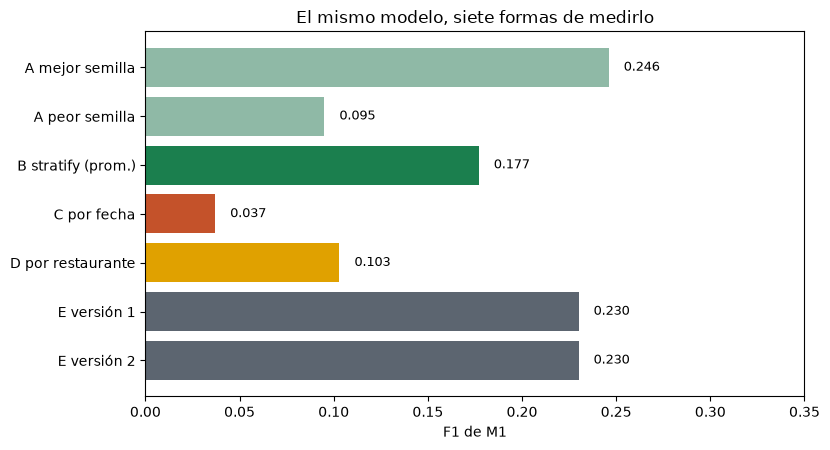

In [16]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
nombres = [
    "A mejor semilla",
    "A peor semilla",
    "B stratify (prom.)",
    "C por fecha",
    "D por restaurante",
    "E versión 1",
    "E versión 2",
]
valores = comparativa["F1 de M1"].tolist()
colores = ["#8FB9A6", "#8FB9A6", "#1B7F4E", "#C4522A", "#E0A100", "#5C6570", "#5C6570"]
ax.barh(nombres[::-1], valores[::-1], color=colores[::-1])
ax.set_xlabel("F1 de M1")
ax.set_xlim(0, 0.35)
ax.set_title("El mismo modelo, siete formas de medirlo")
for i, v in enumerate(valores[::-1]):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(CAPTURAS / "tabla_comparativa_f1.png", dpi=140)
plt.show()


## 11. Para llevar a la clase

**Lo que más sorprendió.** No fue que el F1 cambiara con la semilla: eso se esperaba, aunque no tanto (de 0.095 a 0.246). Lo que sorprendió fue la parte C. Julio–agosto tiene casi la misma tasa global de bajas que enero–junio (9.4 % contra 9.0 %) y, aun así, el F1 se cayó a 0.037. El promedio del período se veía tranquilo; por dentro, julio está en 1.3 % y agosto en 17.8 %. El corte al azar no puede ver ese quiebre porque revuelve los meses. La segunda sorpresa fue la parte E: el atajo de calcular el promedio con todo el archivo no subió el F1. La fuga estaba, pero en este corte era demasiado chica para mover una sola predicción. Una medición inválida puede, de todas formas, verse igual que la válida.

**Una pregunta que quedó abierta.** No se probó un corte por fecha que camine mes a mes (entrenar hasta junio y probar julio; entrenar hasta julio y probar agosto, por separado). Agosto concentra casi todas las bajas del segundo período. ¿El modelo falla en agosto porque el fenómeno cambió, o porque julio —casi sin bajas— diluye el test? Tampoco se midió si reentrenar cada semana recuperaría algo. Esa pregunta importa más que afinar la regresión logística.

**Una regla para el equipo de Ruta Verde.** No califiquemos el modelo con pedidos que ya pasaron mezclados con los que queremos adivinar; califiquémoslo solo con lo que todavía no ha pasado.


## 12. Cómo reproducir

Desde la carpeta del laboratorio, con el entorno del archivo `requirements.txt`:

```text
python -m venv .venv
.venv\Scripts\python.exe -m pip install -r requirements.txt
.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute laboratorio9_particion.ipynb --inplace
```

Las figuras quedan en `docs/capturas/` y la tabla en `docs/tabla_comparativa.csv`.
